# Final Project: Mesoscale Eddies and Surface Chlorophyll Variability in the Gulf of Mexico

### Celina Gong | xg2467

## Description

This project examines whether mesoscale eddies are associated with surface chlorophyll-a variability in the Gulf of Mexico. I combine monthly satellite chlorophyll-a data with the AVISO mesoscale eddy trajectory atlas for cyclonic and anticyclonic eddies.

**Question:** Do cyclonic and anticyclonic eddies show different relationships with surface chlorophyll-a anomalies in the offshore Gulf of Mexico?

**Hypothesis:** Cyclonic eddies are expected to be associated with higher surface chlorophyll-a anomalies than anticyclonic eddies. The reasoning is that cyclonic circulation tends to lift the thermocline and nutricline upward in the eddy core, which can bring more nutrients into the surface layer and support more phytoplankton growth. Anticyclonic eddies push the thermocline downward and are expected to be associated with weaker or lower surface chlorophyll-a anomalies.

**Region and period:** Offshore Gulf of Mexico (longitude 98°W to 80°W, latitude 18°N to 31°N). The analysis covers the time window of the chlorophyll-a file (2018–2025), and the eddy trajectory data are subset to the same window.

**Datasets:**
- Monthly surface chlorophyll-a from the Copernicus Marine Service ocean color product (CMEMS, multi-sensor, 4 km, L4).
- Mesoscale eddy trajectories from the AVISO META 3.2 experimental near-real-time atlas (separate files for cyclonic and anticyclonic eddies).

Both files were downloaded from the official portals and placed in this Final_Project folder, so the notebook reads them directly from disk.


## Setting up the environment

### Python libraries

In [1]:
import os
import warnings
import sys

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import gridspec, patches
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

COL_CYC = "#1F6FB4"
COL_ANT = "#C0392B"

GOM_EXTENT = [-98.0, -80.0, 18.0, 31.0]

### Directories and files

In [2]:
path_base = "/home/xg2467/Final_Project"

chl_file = os.path.join(path_base, "cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1778574517386.nc")
eddy_file_anti = os.path.join(path_base, "Eddy_trajectory_nrt_3.2exp_anticyclonic_20180101_20251229.nc")
eddy_file_cyc = os.path.join(path_base, "Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20251229.nc")

for f in [chl_file, eddy_file_anti, eddy_file_cyc]:
    print(os.path.basename(f), "exists:", os.path.exists(f))
    if os.path.exists(f):
        print("  size MB:", round(os.path.getsize(f) / 1024 / 1024, 2))

cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1778574517386.nc exists: True
  size MB: 49.38
Eddy_trajectory_nrt_3.2exp_anticyclonic_20180101_20251229.nc exists: True
  size MB: 1432.51
Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20251229.nc exists: True
  size MB: 1517.94


### Helper functions

In [3]:
def find_name(ds, possible_names):
    all_names = list(ds.variables)
    lower_lookup = {name.lower(): name for name in all_names}
    for name in possible_names:
        if name in all_names:
            return name
        if name.lower() in lower_lookup:
            return lower_lookup[name.lower()]
    raise ValueError(f"Could not find any of these names: {possible_names}")


def standardize_dataset_longitude(ds, lon_name):
    lon = ds[lon_name]
    if float(lon.max()) > 180:
        new_lon = ((lon + 180) % 360) - 180
        ds = ds.assign_coords({lon_name: new_lon}).sortby(lon_name)
    return ds


def subset_dataarray_box(da, lon_name, lat_name, lon_bounds=(-98, -80), lat_bounds=(18, 31)):
    lon_min, lon_max = lon_bounds
    lat_min, lat_max = lat_bounds

    lat_values = da[lat_name].values
    if lat_values[0] < lat_values[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    return da.sel({lon_name: slice(lon_min, lon_max), lat_name: lat_slice})


def choose_chlorophyll_variable(ds, lon_name, lat_name, time_name):
    available = list(ds.data_vars)

    direct_candidates = ["CHL", "chl", "chlor_a", "chlorophyll", "chlorophyll_a", "CHL_mean"]
    for name in direct_candidates:
        if name in available:
            return name

    for name in available:
        dims = set(ds[name].dims)
        if ("chl" in name.lower()) and {lon_name, lat_name, time_name}.issubset(dims):
            return name


def decode_time_array(time_da):
    values = time_da.values

    if np.issubdtype(values.dtype, np.datetime64):
        return pd.to_datetime(values)

    units = time_da.attrs.get("units", "")
    calendar = time_da.attrs.get("calendar", "standard")

    if "since" in units:
        decoded = xr.coding.times.decode_cf_datetime(values, units=units, calendar=calendar)
        return pd.to_datetime(decoded)

    return pd.to_datetime(values, unit="D", origin="1950-01-01")


def lon_to_180(lon_values):
    return ((lon_values + 180) % 360) - 180


def read_eddy_observations(
    file_path, polarity,
    lon_bounds=(-98, -80), lat_bounds=(18, 31),
    time_start=None, time_end=None,
):
    ds = xr.open_dataset(file_path)

    lon_name = find_name(ds, ["longitude", "lon"])
    lat_name = find_name(ds, ["latitude", "lat"])
    time_name = find_name(ds, ["time"])

    lon = lon_to_180(ds[lon_name].values)
    lat = ds[lat_name].values
    time = decode_time_array(ds[time_name])

    lon_min, lon_max = lon_bounds
    lat_min, lat_max = lat_bounds

    mask = (
        np.isfinite(lon) & np.isfinite(lat)
        & (lon >= lon_min) & (lon <= lon_max)
        & (lat >= lat_min) & (lat <= lat_max)
    )

    if time_start is not None:
        mask = mask & (time >= pd.to_datetime(time_start))
    if time_end is not None:
        mask = mask & (time <= pd.to_datetime(time_end))

    idx = np.where(mask)[0]

    df = pd.DataFrame({
        "time": time[idx],
        "longitude": lon[idx],
        "latitude": lat[idx],
        "polarity": polarity,
    })

    optional_vars = {
        "track": ["track", "track_id", "trajectory"],
        "amplitude": ["amplitude", "amp"],
        "speed_radius": ["speed_radius", "radius", "effective_radius"],
        "speed_average": ["speed_average", "speed"],
    }

    for out_name, candidates in optional_vars.items():
        for candidate in candidates:
            if candidate in ds.data_vars and ds[candidate].dims == ds[lon_name].dims:
                df[out_name] = ds[candidate].values[idx]
                break

    ds.close()
    return df


def savefig(name, dpi=200):
    path = os.path.join(fig_dir, name)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)


def sample_dataarray_at_points(da, df, value_name, lon_name, lat_name, time_name, batch_size=25000):
    values = []
    n = len(df)
    for start in range(0, n, batch_size):
        sub = df.iloc[start:start + batch_size]
        sampled = da.sel(
            {
                lon_name: xr.DataArray(sub["longitude"].to_numpy(), dims="points"),
                lat_name: xr.DataArray(sub["latitude"].to_numpy(), dims="points"),
                time_name: xr.DataArray(sub["time"].to_numpy(dtype="datetime64[ns]"), dims="points"),
            },
            method="nearest",
        )
        values.append(np.asarray(sampled.values))
    return np.concatenate(values)


def add_map_features(ax):
    ax.set_extent(GOM_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("50m"),
                   facecolor="#E8E2D4", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"),
                   linewidth=0.5, zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                       color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = gl.ylabel_style = {"size": 8}


def eddy_centric_composite(sample_df, chl_anom_da, offsets,
                            lon_name, lat_name, time_name):
    n = len(sample_df)
    nb = len(offsets)
    OX, OY = np.meshgrid(offsets, offsets)

    lons_full = sample_df["longitude"].values[:, None, None] + OX[None, :, :]
    lats_full = sample_df["latitude"].values[:, None, None] + OY[None, :, :]
    times_full = np.broadcast_to(
        sample_df["time"].values[:, None, None], (n, nb, nb)
    ).copy()

    df_flat = pd.DataFrame({
        "longitude": lons_full.ravel(),
        "latitude":  lats_full.ravel(),
        "time":      pd.to_datetime(times_full.ravel()),
    })

    vals = sample_dataarray_at_points(
        chl_anom_da, df_flat, "chl_anom",
        lon_name, lat_name, time_name,
        batch_size=50000,
    )

    arr = vals.reshape((n, nb, nb))
    return np.nanmean(arr, axis=0)

## 1) Load and inspect the datasets

In [4]:
ds_chl_raw = xr.open_dataset(chl_file, engine="netcdf4")
ds_anti_preview = xr.open_dataset(eddy_file_anti, engine="netcdf4")
ds_cyc_preview = xr.open_dataset(eddy_file_cyc, engine="netcdf4")

print("Chlorophyll / ocean color dataset:")
print(ds_chl_raw)
print("\nAvailable ocean color variables:", list(ds_chl_raw.data_vars))

print("\nAnticyclonic eddy dataset:")
print(ds_anti_preview)

print("\nCyclonic eddy dataset:")
print(ds_cyc_preview)

Chlorophyll / ocean color dataset:
<xarray.Dataset> Size: 52MB
Dimensions:    (time: 96, latitude: 312, longitude: 432)
Coordinates:
  * time       (time) datetime64[ns] 768B 2018-01-01 2018-02-01 ... 2025-12-01
  * latitude   (latitude) float32 1kB 18.02 18.06 18.1 ... 30.9 30.94 30.98
  * longitude  (longitude) float32 2kB -97.98 -97.94 -97.9 ... -80.06 -80.02
Data variables:
    CHL        (time, latitude, longitude) float32 52MB ...
Attributes:
    Conventions:       CF-1.11
    title:             cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M
    institution:       ACRI
    source:            surface observation
    history:           Created using software developed at ACRI-ST
    contact:           servicedesk.cmems@acri-st.fr
    references:        http://www.globcolour.info GlobColour has been origina...
    comment:           average
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  OCEANCOLOUR_GLO_BGC_L4_MY_009_104
   

## 2) Prepare the chlorophyll-a data

The chlorophyll data are subset to the Gulf of Mexico box used in this project (longitude 98°W to 80°W, latitude 18°N to 31°N).

Chlorophyll-a values are strongly skewed (most pixels have low concentrations, a small number have very high), so I work in log10 space. I compute the monthly climatology over the full record and subtract it from each month to get a chlorophyll-a anomaly in log10 units. This anomaly is the variable I will compare between cyclonic and anticyclonic eddies later in the notebook.


In [5]:
chl_lon_name = find_name(ds_chl_raw, ["longitude", "lon"])
chl_lat_name = find_name(ds_chl_raw, ["latitude", "lat"])
chl_time_name = find_name(ds_chl_raw, ["time"])

DS_chl = standardize_dataset_longitude(ds_chl_raw, chl_lon_name)
chl_var_name = choose_chlorophyll_variable(DS_chl, chl_lon_name, chl_lat_name, chl_time_name)
print("Using chlorophyll variable:", chl_var_name)


chl = DS_chl[chl_var_name].squeeze(drop=True)

chl_gom = subset_dataarray_box(
    chl,
    lon_name=chl_lon_name,
    lat_name=chl_lat_name,
    lon_bounds=(-98, -80),
    lat_bounds=(18, 31),
)

chl_gom = chl_gom.where(np.isfinite(chl_gom) & (chl_gom > 0))

chl_log = np.log10(chl_gom)
chl_log_clim = chl_log.groupby(f"{chl_time_name}.month").mean(chl_time_name)
chl_log_anom = chl_log.groupby(f"{chl_time_name}.month") - chl_log_clim

print(chl_gom)
print("Time range:",
      pd.to_datetime(chl_gom[chl_time_name].min().values), "to",
      pd.to_datetime(chl_gom[chl_time_name].max().values))

Using chlorophyll variable: CHL
<xarray.DataArray 'CHL' (time: 96, latitude: 312, longitude: 432)> Size: 52MB
array([[[       nan,        nan,        nan, ..., 0.10077628,
         0.10178661, 0.10527469],
        [       nan,        nan,        nan, ..., 0.10300595,
         0.10418616, 0.10498685],
        [       nan,        nan,        nan, ..., 0.1035308 ,
         0.1020193 , 0.10122386],
        ...,
        [       nan,        nan,        nan, ..., 0.42303914,
         0.4059898 , 0.39026138],
        [       nan,        nan,        nan, ..., 0.4465237 ,
         0.42551064, 0.40671408],
        [       nan,        nan,        nan, ..., 0.4795384 ,
         0.47931653, 0.44102624]],

       [[       nan,        nan,        nan, ..., 0.10211286,
         0.10273318, 0.10327297],
        [       nan,        nan,        nan, ..., 0.10101248,
         0.10212907, 0.10288575],
        [       nan,        nan,        nan, ..., 0.10138087,
         0.10182821, 0.10177881],
...
       

### Figure 1: Mean chlorophyll-a and its monthly cycle

The left panel shows the time-mean surface chlorophyll-a in the Gulf of Mexico on a log color scale, with coastlines drawn from Natural Earth via Cartopy. The right panel shows the climatological monthly cycle (mean chlorophyll averaged spatially over the box, then grouped by month). This is mainly a sanity check on the chlorophyll product before comparing it with eddies.


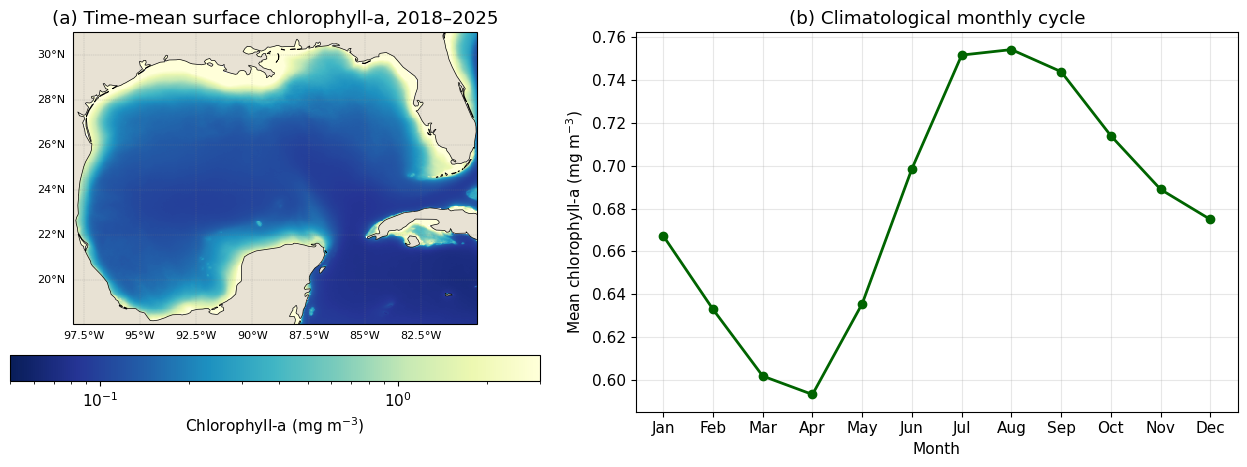

In [6]:
spatial_dims = [chl_lat_name, chl_lon_name]
chl_mean = chl_gom.mean(chl_time_name)
chl_monthly_cycle = chl_gom.mean(spatial_dims).groupby(f"{chl_time_name}.month").mean(chl_time_name)

fig = plt.figure(figsize=(13, 4.8))
proj = ccrs.PlateCarree()

ax1 = fig.add_subplot(1, 2, 1, projection=proj)
add_map_features(ax1)
m1 = ax1.pcolormesh(
    chl_mean[chl_lon_name].values,
    chl_mean[chl_lat_name].values,
    chl_mean.values,
    norm=LogNorm(vmin=0.05, vmax=3),
    cmap="YlGnBu_r",
    shading="auto",
    transform=proj,
    zorder=1,
)
cb = fig.colorbar(m1, ax=ax1, orientation="horizontal", pad=0.08, shrink=0.88)
cb.set_label("Chlorophyll-a (mg m$^{-3}$)")
ax1.set_title("(a) Time-mean surface chlorophyll-a, 2018–2025")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(chl_monthly_cycle["month"].values, chl_monthly_cycle.values,
         marker="o", color="darkgreen", linewidth=2)
ax2.set_xticks(np.arange(1, 13))
ax2.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax2.set_xlabel("Month")
ax2.set_ylabel("Mean chlorophyll-a (mg m$^{-3}$)")
ax2.set_title("(b) Climatological monthly cycle")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3) Prepare the eddy trajectory data

The eddy trajectory data are also subset to the same Gulf of Mexico box and to the same time range as the chlorophyll dataset. I keep cyclonic and anticyclonic eddies as separate DataFrames first, then concatenate them into a single eddy DataFrame with a `polarity` column. The AVISO files also include the eddy amplitude and speed radius, which I keep for later sanity checks.


In [7]:
time_start = pd.to_datetime(chl_gom[chl_time_name].min().values)
time_end = pd.to_datetime(chl_gom[chl_time_name].max().values)

eddy_cyc = read_eddy_observations(
    eddy_file_cyc,
    polarity="Cyclonic",
    lon_bounds=(-98, -80),
    lat_bounds=(18, 31),
    time_start=time_start,
    time_end=time_end,
)

eddy_anti = read_eddy_observations(
    eddy_file_anti,
    polarity="Anticyclonic",
    lon_bounds=(-98, -80),
    lat_bounds=(18, 31),
    time_start=time_start,
    time_end=time_end,
)

eddy_df = pd.concat([eddy_cyc, eddy_anti], ignore_index=True)
eddy_df["year_month"] = eddy_df["time"].dt.to_period("M").dt.to_timestamp()
eddy_df["month"] = eddy_df["time"].dt.month
eddy_df["year"]  = eddy_df["time"].dt.year

print("Number of Gulf of Mexico eddy observations:")
print(eddy_df["polarity"].value_counts())

display(eddy_df.head())

Number of Gulf of Mexico eddy observations:
polarity
Cyclonic        50593
Anticyclonic    38339
Name: count, dtype: int64


,time,longitude,latitude,polarity,track,amplitude,speed_radius,speed_average,year_month,month,year
0,2018-01-01,-94.713806,24.793997,Cyclonic,73,0.0285,65750.0,0.1360,2018-01-01,1,2018
1,2018-01-02,-94.741699,24.832832,Cyclonic,73,0.0200,56400.0,0.1210,2018-01-01,1,2018
2,2018-01-03,-94.713501,24.901146,Cyclonic,73,0.0173,47300.0,0.1222,2018-01-01,1,2018
3,2018-01-04,-94.735748,24.876583,Cyclonic,73,0.0185,49700.0,0.1274,2018-01-01,1,2018
4,2018-01-05,-94.779785,24.841801,Cyclonic,73,0.0189,52050.0,0.1279,2018-01-01,1,2018


### Figure 2: Eddy temporal statistics

This 2×2 figure summarises how the eddy population varies in time. Panel (a) shows the monthly count of cyclonic and anticyclonic observations with a 12-month running mean overlaid in bold. Panel (b) shows the corresponding mean amplitude per month. Panel (c) is the climatological seasonal cycle (each calendar month averaged over all years), and panel (d) is the annual count broken down by polarity.


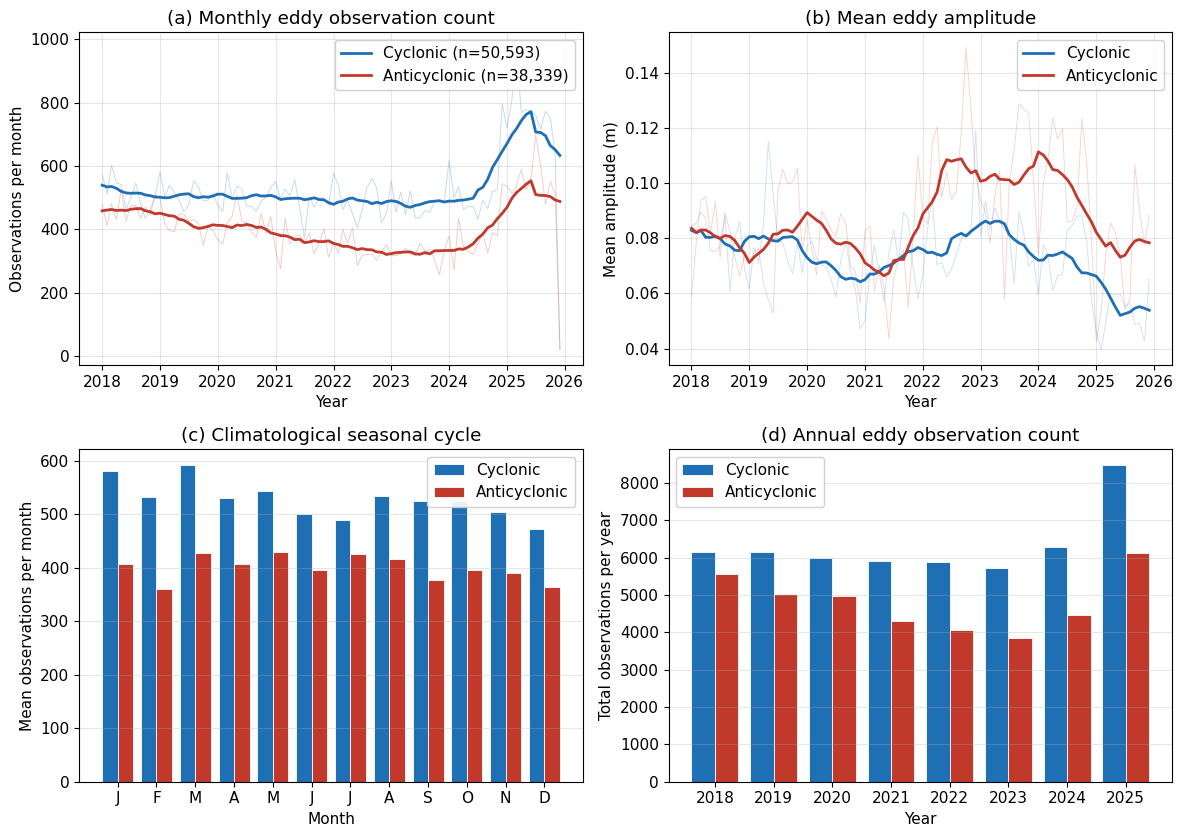

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
fig.subplots_adjust(hspace=0.32, wspace=0.27)

# (a)
ax = axes[0, 0]
grp = eddy_df.groupby(["year_month", "polarity"]).size().unstack("polarity", fill_value=0)
grp_r = grp.rolling(12, center=True, min_periods=6).mean()
ax.plot(grp.index, grp.get("Cyclonic", 0), color=COL_CYC, alpha=0.25, lw=0.7)
ax.plot(grp.index, grp.get("Anticyclonic", 0), color=COL_ANT, alpha=0.25, lw=0.7)
ax.plot(grp_r.index, grp_r.get("Cyclonic", 0), color=COL_CYC, lw=2.0,
        label=f"Cyclonic (n={(eddy_df.polarity=='Cyclonic').sum():,})")
ax.plot(grp_r.index, grp_r.get("Anticyclonic", 0), color=COL_ANT, lw=2.0,
        label=f"Anticyclonic (n={(eddy_df.polarity=='Anticyclonic').sum():,})")
ax.set_ylabel("Observations per month"); ax.set_xlabel("Year")
ax.set_title("(a) Monthly eddy observation count")
ax.legend(loc="upper right", framealpha=0.9); ax.grid(alpha=0.3)

# (b)
ax = axes[0, 1]
amp_grp = (eddy_df.groupby(["year_month", "polarity"])["amplitude"]
              .mean().unstack("polarity"))
amp_grp = amp_grp.resample("MS").mean()
amp_r = amp_grp.interpolate(method="linear", limit=3).rolling(12, center=True, min_periods=6).mean()
ax.plot(amp_grp.index, amp_grp.get("Cyclonic"), color=COL_CYC, alpha=0.20, lw=0.7)
ax.plot(amp_grp.index, amp_grp.get("Anticyclonic"), color=COL_ANT, alpha=0.20, lw=0.7)
ax.plot(amp_r.index, amp_r.get("Cyclonic"), color=COL_CYC, lw=2.0, label="Cyclonic")
ax.plot(amp_r.index, amp_r.get("Anticyclonic"), color=COL_ANT, lw=2.0, label="Anticyclonic")
ax.set_ylabel("Mean amplitude (m)"); ax.set_xlabel("Year")
ax.set_title("(b) Mean eddy amplitude")
ax.legend(framealpha=0.9); ax.grid(alpha=0.3)

# (c)
ax = axes[1, 0]
months = np.arange(1, 13)
season = (eddy_df.groupby(["month", "polarity"]).size()
            .unstack("polarity", fill_value=0)
            / len(eddy_df["year"].unique()))
bw = 0.4
ax.bar(months - bw/2, season.get("Cyclonic", 0), width=bw, color=COL_CYC,
       label="Cyclonic", edgecolor="white", lw=0.6)
ax.bar(months + bw/2, season.get("Anticyclonic", 0), width=bw, color=COL_ANT,
       label="Anticyclonic", edgecolor="white", lw=0.6)
ax.set_xticks(months); ax.set_xticklabels(list("JFMAMJJASOND"))
ax.set_ylabel("Mean observations per month"); ax.set_xlabel("Month")
ax.set_title("(c) Climatological seasonal cycle")
ax.legend(framealpha=0.9); ax.grid(alpha=0.3, axis="y")

# (d)
ax = axes[1, 1]
yr = (eddy_df.groupby(["year", "polarity"]).size()
         .unstack("polarity", fill_value=0))
yrs = yr.index.astype(int)
ax.bar(yrs - 0.2, yr.get("Cyclonic", 0), width=0.4, color=COL_CYC,
       label="Cyclonic", edgecolor="white", lw=0.6)
ax.bar(yrs + 0.2, yr.get("Anticyclonic", 0), width=0.4, color=COL_ANT,
       label="Anticyclonic", edgecolor="white", lw=0.6)
ax.set_ylabel("Total observations per year"); ax.set_xlabel("Year")
ax.set_title("(d) Annual eddy observation count")
ax.set_xticks(yrs[::max(1, len(yrs)//9)])
ax.legend(framealpha=0.9); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Figure 3: Eddy property distributions

This is a quick sanity check on the eddy physical properties. Panel (a) is the amplitude distribution, (b) is the speed radius distribution, (c) is the joint scatter of amplitude vs. radius (a known correlation in mesoscale eddies), and (d) is the latitudinal distribution of eddy centers. The two polarities have generally similar distributions, with anticyclonic eddies tending to be slightly larger and more energetic in this region — the Loop Current rings are dominantly anticyclonic.


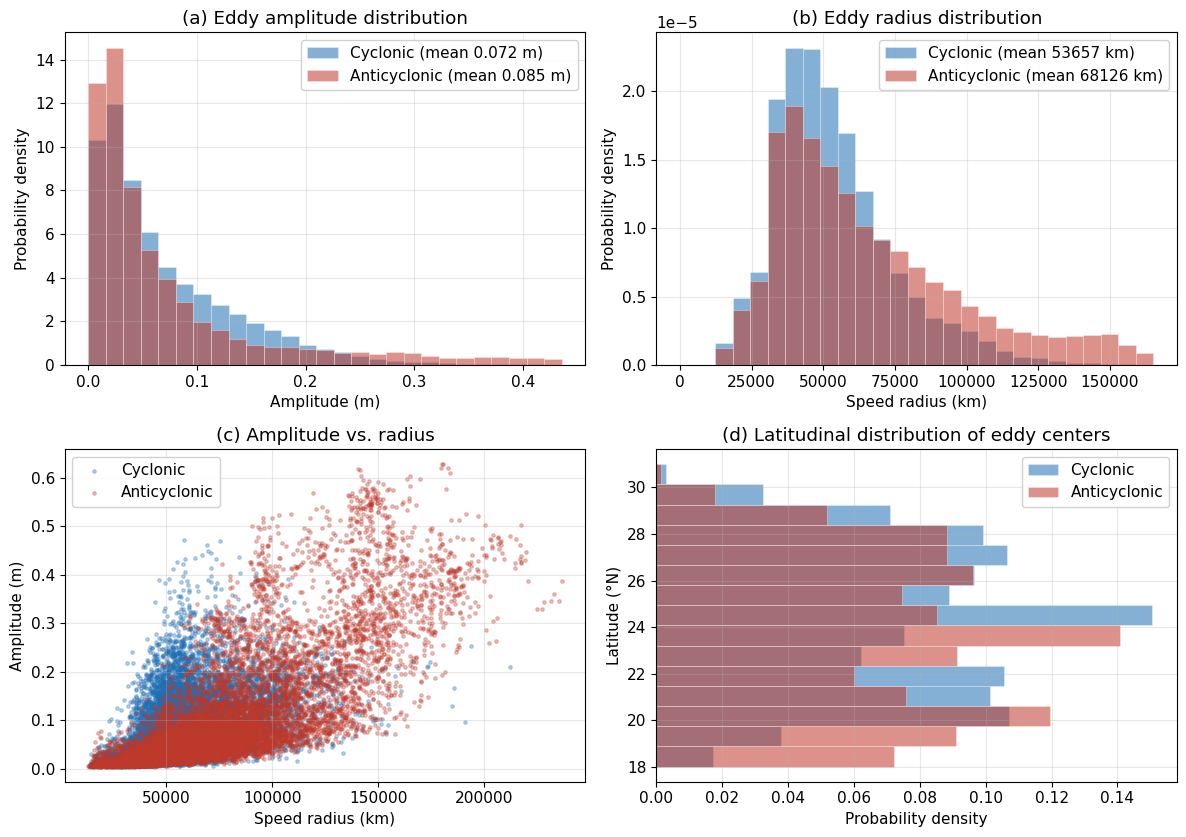

In [9]:
ce = eddy_df[eddy_df.polarity == "Cyclonic"]
ae = eddy_df[eddy_df.polarity == "Anticyclonic"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
fig.subplots_adjust(hspace=0.32, wspace=0.27)

# (a)
ax = axes[0, 0]
amp_max = max(eddy_df["amplitude"].quantile(0.99), 0.4)
bins = np.linspace(0, amp_max, 28)
ax.hist(ce["amplitude"], bins=bins, alpha=0.55, color=COL_CYC, density=True,
        edgecolor="white", lw=0.4,
        label=f"Cyclonic (mean {ce['amplitude'].mean():.3f} m)")
ax.hist(ae["amplitude"], bins=bins, alpha=0.55, color=COL_ANT, density=True,
        edgecolor="white", lw=0.4,
        label=f"Anticyclonic (mean {ae['amplitude'].mean():.3f} m)")
ax.set_xlabel("Amplitude (m)"); ax.set_ylabel("Probability density")
ax.set_title("(a) Eddy amplitude distribution")
ax.legend(framealpha=0.9); ax.grid(alpha=0.3)

# (b)
ax = axes[0, 1]
rad_max = max(eddy_df["speed_radius"].quantile(0.99), 250)
bins = np.linspace(20, rad_max, 28)
ax.hist(ce["speed_radius"], bins=bins, alpha=0.55, color=COL_CYC, density=True,
        edgecolor="white", lw=0.4,
        label=f"Cyclonic (mean {ce['speed_radius'].mean():.0f} km)")
ax.hist(ae["speed_radius"], bins=bins, alpha=0.55, color=COL_ANT, density=True,
        edgecolor="white", lw=0.4,
        label=f"Anticyclonic (mean {ae['speed_radius'].mean():.0f} km)")
ax.set_xlabel("Speed radius (km)"); ax.set_ylabel("Probability density")
ax.set_title("(b) Eddy radius distribution")
ax.legend(framealpha=0.9); ax.grid(alpha=0.3)

# (c)
ax = axes[1, 0]
ce_s = ce.sample(min(len(ce), 15000), random_state=42)
ae_s = ae.sample(min(len(ae), 15000), random_state=42)
ax.scatter(ce_s["speed_radius"], ce_s["amplitude"], c=COL_CYC, alpha=0.30, s=6, label="Cyclonic")
ax.scatter(ae_s["speed_radius"], ae_s["amplitude"], c=COL_ANT, alpha=0.30, s=6, label="Anticyclonic")
ax.set_xlabel("Speed radius (km)"); ax.set_ylabel("Amplitude (m)")
ax.set_title("(c) Amplitude vs. radius"); ax.legend(framealpha=0.9); ax.grid(alpha=0.3)

# (d)
ax = axes[1, 1]
lat_bins = np.linspace(18, 31, 16)
ax.hist(ce["latitude"], bins=lat_bins, alpha=0.55, color=COL_CYC, density=True,
        edgecolor="white", lw=0.4, orientation="horizontal", label="Cyclonic")
ax.hist(ae["latitude"], bins=lat_bins, alpha=0.55, color=COL_ANT, density=True,
        edgecolor="white", lw=0.4, orientation="horizontal", label="Anticyclonic")
ax.set_ylabel("Latitude (°N)"); ax.set_xlabel("Probability density")
ax.set_title("(d) Latitudinal distribution of eddy centers")
ax.legend(framealpha=0.9, loc="upper right"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Figure 4: Spatial distribution of eddy centers

Hexbin maps of all eddy observations in the Gulf of Mexico box over 2018–2025, with cyclonic on the left and anticyclonic on the right. Each hexbin is shaded by the number of eddy observations inside it. The Loop Current band around 25–27°N stands out, especially for anticyclonic eddies which include the warm-core Loop Current Rings shed from the eastern Gulf and propagating westward.


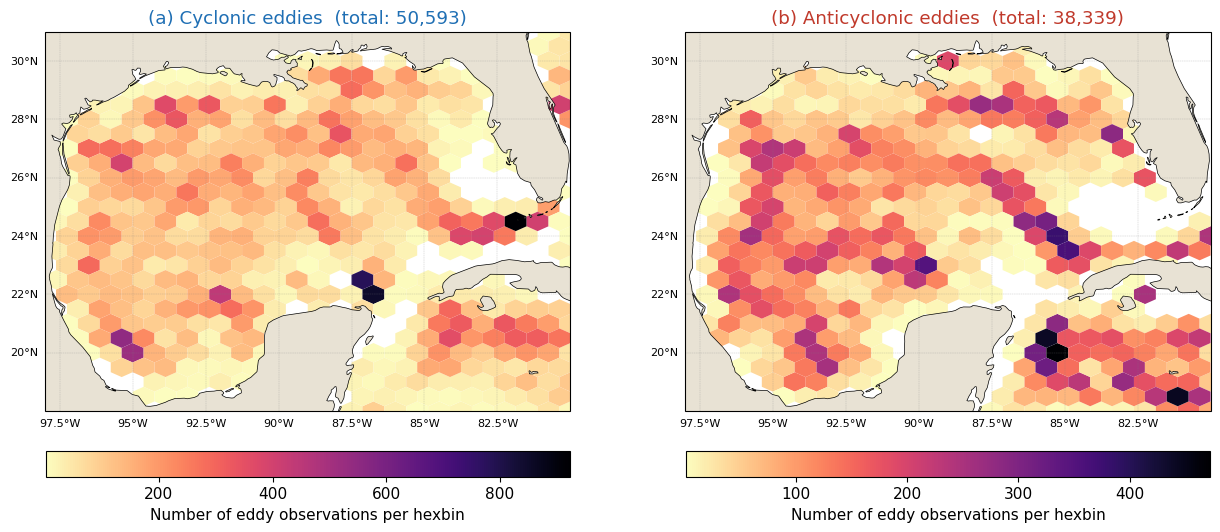

In [10]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 5.5))

for k, (pol, title, col) in enumerate([
    ("Cyclonic", "(a) Cyclonic eddies", COL_CYC),
    ("Anticyclonic", "(b) Anticyclonic eddies", COL_ANT),
]):
    ax = fig.add_subplot(1, 2, k+1, projection=proj)
    add_map_features(ax)
    sub = eddy_df[eddy_df.polarity == pol]
    hb = ax.hexbin(sub.longitude, sub.latitude, gridsize=24, extent=GOM_EXTENT,
                    cmap="magma_r", mincnt=1, edgecolors="none",
                    transform=proj, zorder=1)
    cb = fig.colorbar(hb, ax=ax, orientation="horizontal", pad=0.08, shrink=0.88)
    cb.set_label("Number of eddy observations per hexbin")
    ax.set_title(f"{title}  (total: {len(sub):,})", color=col)

plt.tight_layout()
plt.show()

## 4) Match eddy observations with chlorophyll anomalies

For each eddy observation, I sample the nearest monthly chlorophyll-a value and the nearest monthly chlorophyll-a anomaly. The total number of eddy observations is very large, so I cap each polarity at 250,000 observations using a random sample. This keeps the nearest-neighbour lookup fast while still giving a very large sample for statistics.


In [11]:
MAX_POINTS_PER_POLARITY = 250000

match_parts = []
for pol, sub in eddy_df.groupby("polarity"):
    match_parts.append(sub.sample(min(len(sub), MAX_POINTS_PER_POLARITY), random_state=42))
match_df = pd.concat(match_parts, ignore_index=True)

print("Number of eddy observations used for chlorophyll matching:")
print(match_df["polarity"].value_counts())

match_df["log10_chl"] = sample_dataarray_at_points(
    chl_log, match_df, value_name="log10_chl",
    lon_name=chl_lon_name, lat_name=chl_lat_name, time_name=chl_time_name,
)

match_df["log10_chl_anom"] = sample_dataarray_at_points(
    chl_log_anom, match_df, value_name="log10_chl_anom",
    lon_name=chl_lon_name, lat_name=chl_lat_name, time_name=chl_time_name,
)

match_df = match_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["log10_chl", "log10_chl_anom"])

display(match_df.head())

Number of eddy observations used for chlorophyll matching:
polarity
Cyclonic        50593
Anticyclonic    38339
Name: count, dtype: int64


,time,longitude,latitude,polarity,track,amplitude,speed_radius,speed_average,year_month,month,year,log10_chl,log10_chl_anom
0,2023-12-21,-93.679840,19.720572,Anticyclonic,165861,0.0525,56450.0,0.2683,2023-12-01,12,2023,-0.724718,-0.011097
1,2019-01-21,-80.026001,19.656015,Anticyclonic,30822,0.0184,46000.0,0.1532,2019-01-01,1,2019,-1.017018,0.042040
2,2020-03-02,-92.407959,21.232178,Anticyclonic,59754,0.0332,75750.0,0.1586,2020-03-01,3,2020,-0.725987,0.101440
3,2022-05-04,-81.264008,18.807735,Anticyclonic,118468,0.0083,29650.0,0.1490,2022-05-01,5,2022,-1.188549,0.052793
4,2020-07-17,-91.681580,23.905470,Anticyclonic,58680,0.2718,113150.0,0.5409,2020-07-01,7,2020,-1.180046,-0.039602


### Figure 5: Spatial pattern of eddy-associated chlorophyll-a anomalies

I bin the eddy observations on a 1° grid and within each grid cell I compute the mean log10 chlorophyll-a anomaly. The left panel shows the result for cyclonic eddies and the right panel for anticyclonic eddies. Both panels use the same diverging color scale (red = positive anomaly, blue = negative). If the hypothesis holds in space, I expect the cyclonic panel to be redder overall and the anticyclonic panel to be bluer.


/tmp/ipykernel_441824/2441617569.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdf.groupby(["lat_bin", "lon_bin", "polarity"])["log10_chl_anom"]


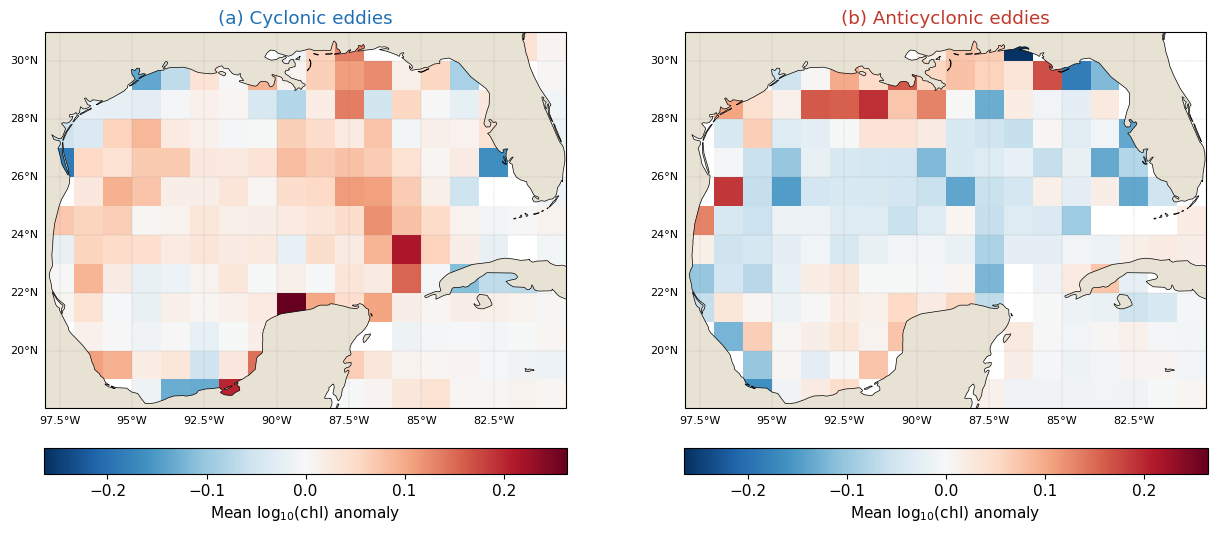

In [12]:
lon_bins = np.arange(-98, -79, 1)
lat_bins = np.arange(18, 32, 1)

mdf = match_df.copy()
mdf["lon_bin"] = pd.cut(mdf["longitude"], bins=lon_bins, labels=lon_bins[:-1] + 0.5)
mdf["lat_bin"] = pd.cut(mdf["latitude"],  bins=lat_bins, labels=lat_bins[:-1] + 0.5)

binned = (
    mdf.groupby(["lat_bin", "lon_bin", "polarity"])["log10_chl_anom"]
       .mean().reset_index()
)


vmax = 0.0
for pol in ["Cyclonic", "Anticyclonic"]:
    tmp = binned[binned["polarity"] == pol]
    grid = tmp.pivot(index="lat_bin", columns="lon_bin", values="log10_chl_anom").astype(float)
    if grid.values.size:
        vmax = max(vmax, np.nanmax(np.abs(grid.values)))
vmax = min(max(vmax, 0.05), 0.3)

fig = plt.figure(figsize=(13, 5.5))
proj = ccrs.PlateCarree()
for k, polarity in enumerate(["Cyclonic", "Anticyclonic"]):
    ax = fig.add_subplot(1, 2, k+1, projection=proj)
    add_map_features(ax)
    tmp = binned[binned["polarity"] == polarity]
    grid = tmp.pivot(index="lat_bin", columns="lon_bin", values="log10_chl_anom").astype(float)
    pc = ax.pcolormesh(
        grid.columns.astype(float), grid.index.astype(float),
        grid.values, shading="auto",
        cmap="RdBu_r", vmin=-vmax, vmax=vmax,
        transform=proj, zorder=1,
    )
    cb = fig.colorbar(pc, ax=ax, orientation="horizontal", pad=0.08, shrink=0.88)
    cb.set_label("Mean log$_{10}$(chl) anomaly")
    col = COL_CYC if polarity == "Cyclonic" else COL_ANT
    ax.set_title(f"({chr(97+k)}) {polarity} eddies", color=col)

plt.tight_layout()
plt.show()

### Figure 6: Hypothesis test — chlorophyll-a anomaly vs. eddy polarity

This is the central figure of the project. Panel (a) is a boxplot of the matched log10 chlorophyll-a anomaly, split by polarity; the diamond markers show the means. Panel (b) is an "eddy-centric composite": for each eddy in a random subsample I extract the chlorophyll-a anomaly at the eddy time on a grid of offsets within ±2° of the eddy center, then average over all eddies. The black circle marks 1° (about 100 km), a typical mesoscale eddy radius.

If the hypothesis holds, the cyclonic box should sit above zero and the anticyclonic box below, and the cyclonic composite should be red inside the circle while the anticyclonic composite should be blue.


,mean,median,std,count
polarity,,,,
Anticyclonic,-0.017942,-0.014385,0.124911,38331
Cyclonic,0.025295,0.016159,0.127795,50577


/tmp/ipykernel_441824/645993533.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Cyclonic", "Anticyclonic"],


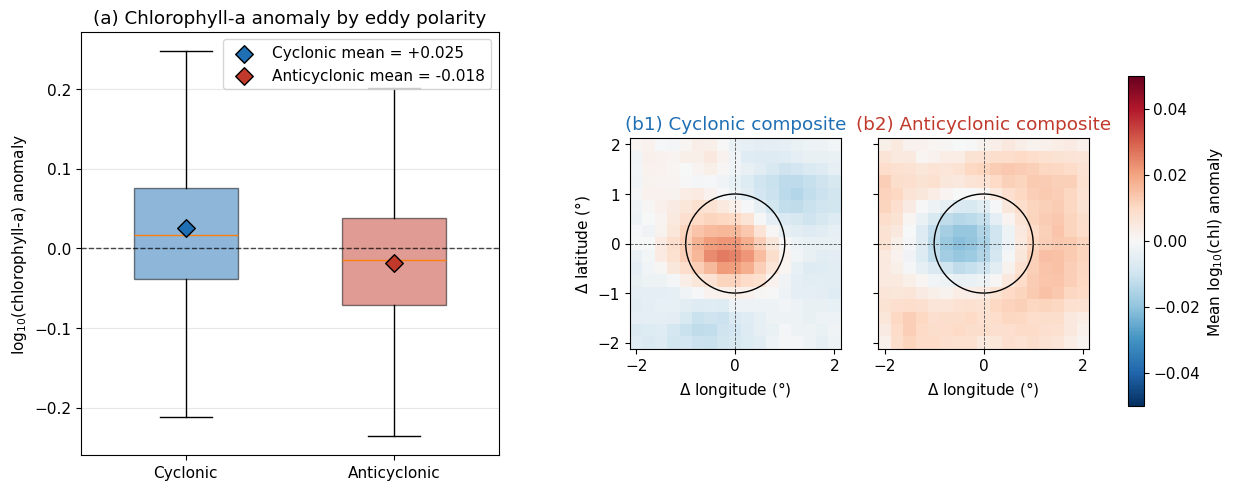

In [13]:
summary_chl = match_df.groupby("polarity")["log10_chl_anom"].agg(["mean", "median", "std", "count"])
display(summary_chl)

N_COMP = 3000
comp_parts = []
for pol, sub in match_df.groupby("polarity"):
    comp_parts.append(sub.sample(min(len(sub), N_COMP), random_state=42))
comp_sample = pd.concat(comp_parts, ignore_index=True)

offsets = np.arange(-2.0, 2.001, 0.25)
ce_comp = eddy_centric_composite(
    comp_sample[comp_sample["polarity"] == "Cyclonic"],
    chl_log_anom, offsets, chl_lon_name, chl_lat_name, chl_time_name,
)
ae_comp = eddy_centric_composite(
    comp_sample[comp_sample["polarity"] == "Anticyclonic"],
    chl_log_anom, offsets, chl_lon_name, chl_lat_name, chl_time_name,
)



fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.30, width_ratios=[1, 1.10])

# (a)
ax = fig.add_subplot(gs[0, 0])
data = [
    match_df.loc[match_df["polarity"]=="Cyclonic", "log10_chl_anom"].dropna(),
    match_df.loc[match_df["polarity"]=="Anticyclonic", "log10_chl_anom"].dropna(),
]
bp = ax.boxplot(data, labels=["Cyclonic", "Anticyclonic"],
                 showfliers=False, patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [COL_CYC, COL_ANT]):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
ax.set_ylabel(r"log$_{10}$(chlorophyll-a) anomaly")
ax.set_title("(a) Chlorophyll-a anomaly by eddy polarity")
ax.grid(axis="y", alpha=0.3)

ce_mean_v = match_df.loc[match_df["polarity"]=="Cyclonic", "log10_chl_anom"].mean()
ae_mean_v = match_df.loc[match_df["polarity"]=="Anticyclonic", "log10_chl_anom"].mean()
ax.scatter([1], [ce_mean_v], marker="D", color=COL_CYC, edgecolor="black",
            s=80, zorder=10, label=f"Cyclonic mean = {ce_mean_v:+.3f}")
ax.scatter([2], [ae_mean_v], marker="D", color=COL_ANT, edgecolor="black",
            s=80, zorder=10, label=f"Anticyclonic mean = {ae_mean_v:+.3f}")
ax.legend(loc="upper right")

# (b)
gs_in = gs[0, 1].subgridspec(1, 2, wspace=0.18)
ax_ce = fig.add_subplot(gs_in[0, 0])
ax_ae = fig.add_subplot(gs_in[0, 1])

OX, OY = np.meshgrid(offsets, offsets)
vmax_c = max(np.nanmax(np.abs(ce_comp)), np.nanmax(np.abs(ae_comp)), 0.05)

pcm1 = ax_ce.pcolormesh(OX, OY, ce_comp, cmap="RdBu_r",
                         vmin=-vmax_c, vmax=vmax_c, shading="auto")
pcm2 = ax_ae.pcolormesh(OX, OY, ae_comp, cmap="RdBu_r",
                         vmin=-vmax_c, vmax=vmax_c, shading="auto")
for a, title, col in [(ax_ce, "(b1) Cyclonic composite", COL_CYC),
                       (ax_ae, "(b2) Anticyclonic composite", COL_ANT)]:
    a.set_aspect("equal")
    a.set_xlabel(r"$\Delta$ longitude (°)")
    a.set_title(title, color=col)
    a.axhline(0, color="0.3", lw=0.6, linestyle="--")
    a.axvline(0, color="0.3", lw=0.6, linestyle="--")
    a.add_patch(patches.Circle((0,0), 1.0, fill=False, edgecolor="black", lw=1.0))
ax_ce.set_ylabel(r"$\Delta$ latitude (°)")
ax_ae.set_yticklabels([])

cax = fig.add_axes([0.93, 0.20, 0.012, 0.6])
fig.colorbar(pcm2, cax=cax, label=r"Mean log$_{10}$(chl) anomaly")

plt.show()

## 5) Main results and discussion

In [14]:
cyc_mean = summary_chl.loc["Cyclonic", "mean"] if "Cyclonic" in summary_chl.index else np.nan
anti_mean = summary_chl.loc["Anticyclonic", "mean"] if "Anticyclonic" in summary_chl.index else np.nan
difference = cyc_mean - anti_mean

print(f"Cyclonic mean log10(chl) anomaly:     {cyc_mean:+.4f}")
print(f"Anticyclonic mean log10(chl) anomaly: {anti_mean:+.4f}")
print(f"Difference (cyclonic - anticyclonic): {difference:+.4f}")
print(f"Number of cyclonic samples:     {int(summary_chl.loc['Cyclonic', 'count']):,}")
print(f"Number of anticyclonic samples: {int(summary_chl.loc['Anticyclonic', 'count']):,}")

Cyclonic mean log10(chl) anomaly:     +0.0253
Anticyclonic mean log10(chl) anomaly: -0.0179
Difference (cyclonic - anticyclonic): +0.0432
Number of cyclonic samples:     50,577
Number of anticyclonic samples: 38,331


## Summary

This project examined whether mesoscale eddy polarity is related to surface chlorophyll-a variability in the Gulf of Mexico. Monthly satellite chlorophyll-a data were converted to log10 anomalies by removing the monthly climatology. Eddy observations were then matched with the nearest chlorophyll-a anomaly values and grouped by polarity.

The results show that cyclonic eddy observations have a higher mean log10 chlorophyll-a anomaly than anticyclonic observations. The cyclonic mean anomaly is 0.0253, while the anticyclonic mean anomaly is -0.0179. The difference between the two groups is about 0.0432. This pattern supports the idea that cyclonic eddies are more strongly associated with enhanced surface chlorophyll-a in the Gulf of Mexico.

The main limitation is that this analysis uses monthly gridded chlorophyll-a data sampled at eddy observation locations. It does not fully resolve short-lived biological responses or the detailed spatial structure within each eddy. A stronger version of this project would compare chlorophyll-a inside and outside eddy boundaries and use higher-frequency data when available.